In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression ,RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler


import warnings 
warnings.filterwarnings('ignore')

In [263]:
data = pd.read_csv("seattle-weather.csv")
data

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [264]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [265]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [266]:
data["weather"].unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

In [267]:
def month(text):
    return text[5:7]

data.insert(0,"month",value=data["date"].apply(month))

In [268]:
data.drop("date",inplace=True,axis=1)

In [269]:
data.isna().sum()

month            0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [270]:
data["weather"].unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

In [271]:
class_count = data["weather"].value_counts()

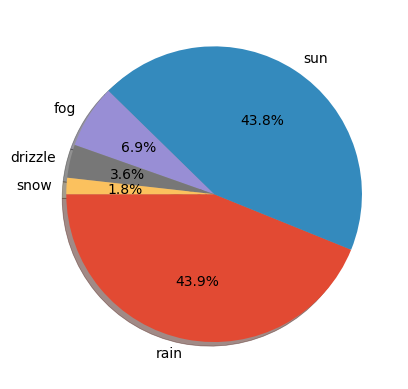

In [272]:

plt.pie(x=class_count.values,labels=class_count.index,autopct="%1.1f%%",shadow=True,startangle=180)
plt.show()

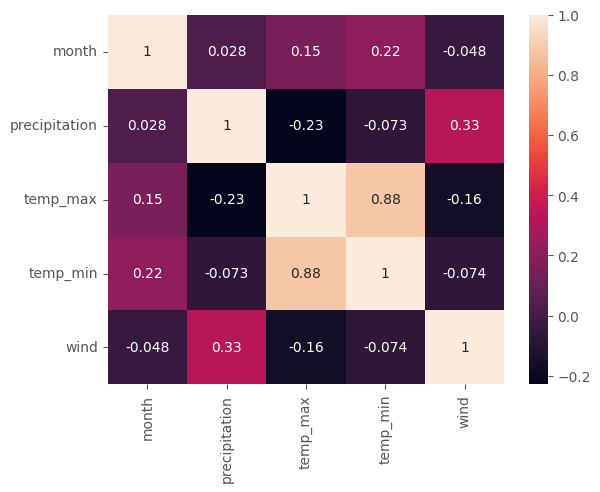

In [273]:
corr = data.iloc[:,:-1].corr()
sns.heatmap(corr,annot=True)
plt.show()

In [274]:
fetures = data.iloc[:,:-1]
classes = data.iloc[:,-1]
x_train ,x_test  , y_train , y_test = train_test_split(fetures,classes,test_size=0.2,shuffle=True,random_state=42)

In [275]:
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)
train_resampled = pd.concat([pd.DataFrame(X_train_resampled, columns=x_train.columns),pd.Series(y_train_resampled, name="weather")],axis=1)


In [276]:
test_df = pd.concat([x_test.reset_index(drop=True),y_test.reset_index(drop=True)],axis=1)
full_dataset = pd.concat([train_resampled, test_df],axis=0).reset_index(drop=True)


In [277]:
class_count = full_dataset["weather"].value_counts()

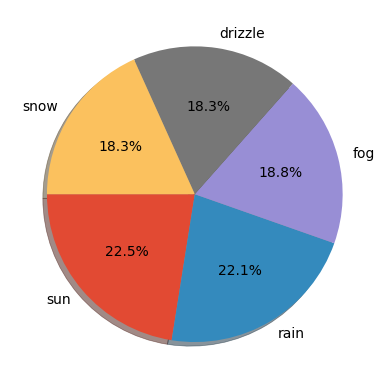

In [278]:

plt.pie(x=class_count.values,labels=class_count.index,autopct="%1.1f%%",shadow=True,startangle=180)
plt.show()

In [280]:
classweights = compute_class_weight(classes=np.unique(classes),class_weight="balanced",y=classes)
classweights = dict(zip(np.unique(classes), classweights))
classweights

{'drizzle': np.float64(5.513207547169811),
 'fog': np.float64(2.893069306930693),
 'rain': np.float64(0.45585023400936037),
 'snow': np.float64(11.238461538461538),
 'sun': np.float64(0.4565625)}

In [281]:
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42,class_weight=classweights),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight=classweights),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVC": SVC(random_state=42,class_weight=classweights),
    "Decision Tree": DecisionTreeClassifier(random_state=42,class_weight=classweights,max_depth=7),
    "Extra Trees": ExtraTreesClassifier(random_state=42,class_weight=classweights),
    "Ridge Classifier": RidgeClassifier(random_state=42,class_weight=classweights)
}

ml_results = {}
for name, model in ml_models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    ml_results[name] = accuracy_score(y_test, preds)

In [282]:
all_results = sorted(ml_results.items(),key=lambda x: x[1],reverse=True)
all_results = dict(all_results)
all_results

{'Gradient Boosting': 0.8464163822525598,
 'AdaBoost': 0.8293515358361775,
 'Random Forest': 0.8225255972696246,
 'Extra Trees': 0.8156996587030717,
 'Decision Tree': 0.6860068259385665,
 'Logistic Regression': 0.6552901023890785,
 'SVC': 0.6450511945392492,
 'Ridge Classifier': 0.552901023890785}

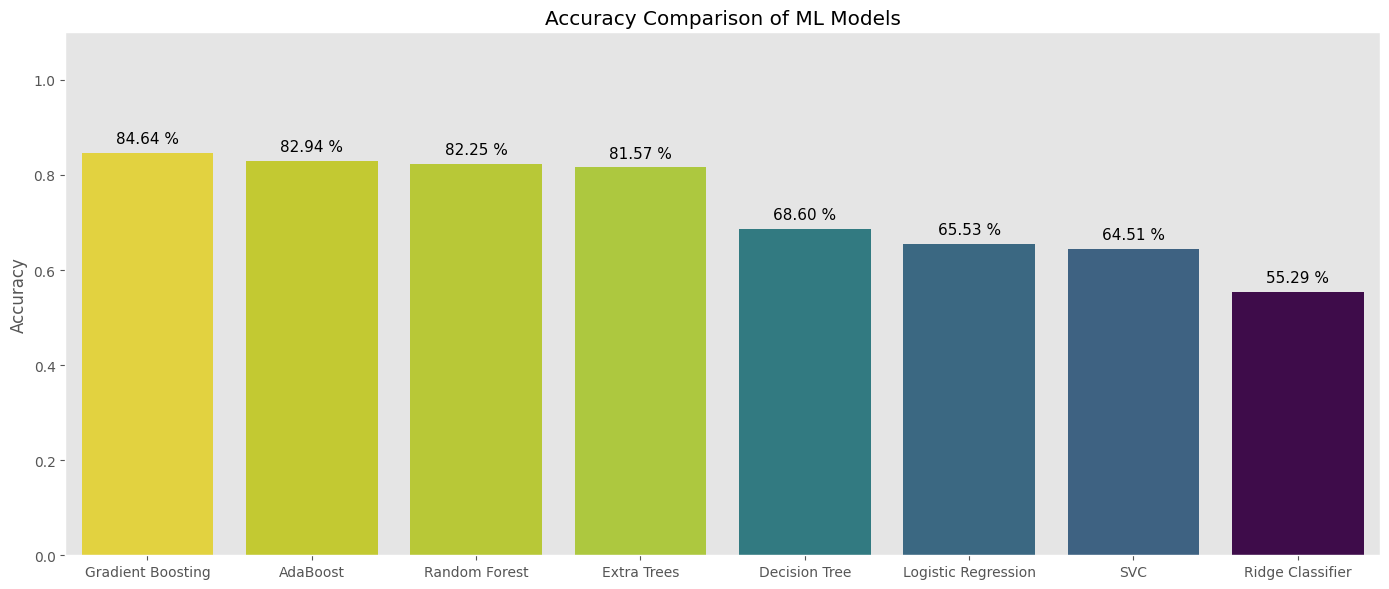

In [283]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=list(all_results.keys()),y=list(all_results.values()),palette="viridis",hue=list(all_results.values()),legend=False)
plt.title("Accuracy Comparison of ML Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 1.1)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.2f} %",(p.get_x() + p.get_width() / 2, height),ha="center",va="bottom",fontsize=11,xytext=(0, 5),textcoords="offset points")

plt.tight_layout()
plt.grid(False)
plt.show()

In [288]:
model = ml_models["Gradient Boosting"]
preds = model.predict(x_test)

In [289]:
print("Accuracy:", accuracy_score(y_test, preds) * 100)


Accuracy: 84.64163822525597


In [290]:
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

     drizzle       0.50      0.11      0.18         9
         fog       0.78      0.28      0.41        25
        rain       0.95      0.92      0.93       120
        snow       0.40      0.25      0.31         8
         sun       0.80      0.98      0.88       131

    accuracy                           0.85       293
   macro avg       0.68      0.51      0.54       293
weighted avg       0.84      0.85      0.82       293



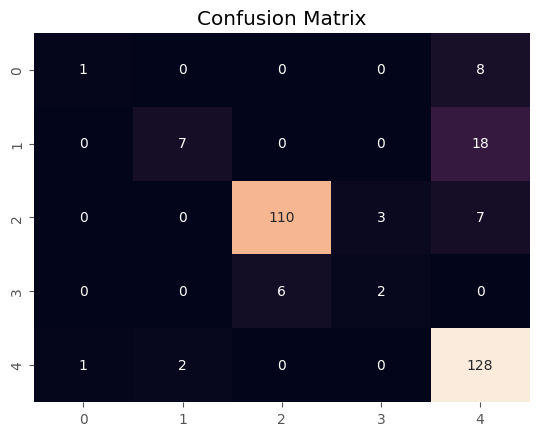

In [291]:
sns.heatmap(data=confusion_matrix(y_test, preds),annot=True,fmt=".0f",cbar=False)
plt.title("Confusion Matrix")
plt.show()

In [292]:
month_2 = 12 #datetime.datetime.now().month
if month_2 in range(1,10):
    print(0)
    str_month = "0" + str(month_2)
    test = pd.DataFrame({"month":[str_month],"precipitation":[0],"temp_max":[30],"temp_min":[18],"wind":[15]})
    result = model.predict(test)
    print(result)
else:
    str1_month = str(month_2)
    test = pd.DataFrame({"month":[str1_month],"precipitation":[0],"temp_max":[30],"temp_min":[10],"wind":[15]})
    result = model.predict(test)
    print(result)
    


['fog']
